# **Project Name** - Yes Bank Stock Price Prediction

##### **Project Type** - Regression

##### **Contribution** - Individual

##### **Member Name** - Pragati Maurya

# **Project Summary** -

Yes Bank, a prominent player in the Indian financial sector, experienced significant volatility following the 2018 fraud case involving Rana Kapoor. This project focuses on building a machine learning regression model to predict the monthly closing price of Yes Bank stock. The dataset spans from the bank's inception through November 2020, capturing the drastic price fluctuations during the period of financial instability.

The workflow follows a rigorous Data Science lifecycle:

->Data Exploration: Understanding the distributions of Open, High, Low, and Close prices.

->Preprocessing: Handling the date format (converting strings to datetime objects) and checking for missing values or outliers.

->Feature Engineering: Dealing with multicollinearity, as stock price features (OHLC) are often highly correlated.

->Modeling: Implementing multiple regression algorithms, including Linear Regression, Lasso, and Ridge, to find the most robust predictor.

->Evaluation: Using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R^2 Score to assess performance.

The goal is to determine if predictive models can accurately capture the stock's behavior despite the external shocks caused by the fraud scandal.

#**GitHub Link** -

https://github.com/PragatiMaurya16

# **Problem Statement**-

The objective is to predict the stock's Closing Price for a given month based on that month's Opening, Highest, and Lowest prices. Given the history of the Rana Kapoor fraud case, the model must handle high variance and non-linear trends in the data.


#**1. Know Your Data**

In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
#Load Data

from google.colab import files
upload = files.upload()

Saving data_YesBank_StockPrices.csv to data_YesBank_StockPrices.csv


In [4]:
df = pd.read_csv('data_YesBank_StockPrices.csv')

In [7]:
#Dataset Information

df.head()    # First five rows

print("Shape:", df.shape)    # Shape of dataset

df.info()   # Dataset info

df.describe()    # Statistical Summary

Shape: (185, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


#**2. Understanding the Variable**

#Variables Description

##Fields--Description

Date--Date of record (Monthly)

Open--Opening Price of the month

High--Highest price in the month

Low--Lowest price in the month

Close--Target Variable: Closing price of the month

In [8]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64
Duplicate Rows: 0


There are no missing (null/empty) values in that column.


There are no duplicate rows in the dataset.




##**3. Data Wrangling**

In [9]:
# Convert Date to datetime format
df['Date'] = df['Date'].apply(lambda x: datetime.strptime(x, "%b-%y"))

To enable proper time-series analysis and visualization.

#**4. Data Visualization**

Understanding relationships between variables using charts.


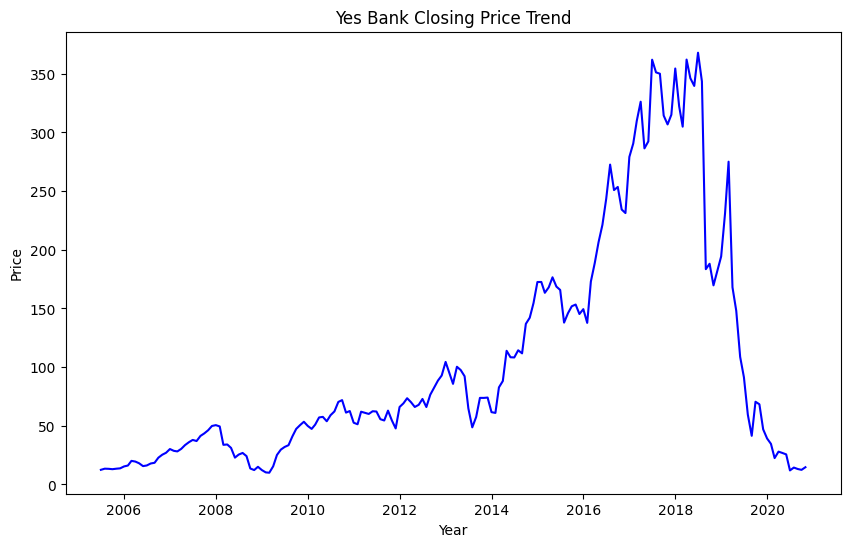

In [10]:
#Trend of Closing Price Over Time

plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Yes Bank Closing Price Trend')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

->It helps distinguish between the long-term growth regime and the sudden period of extreme volatility and decline

->The closing stock price of Yes Bank showed strong growth until 2018, followed by a major decline after 2018. The graph clearly indicates high volatility in stock performance over time.

->Understanding this trend is vital for building a robust predictive mode

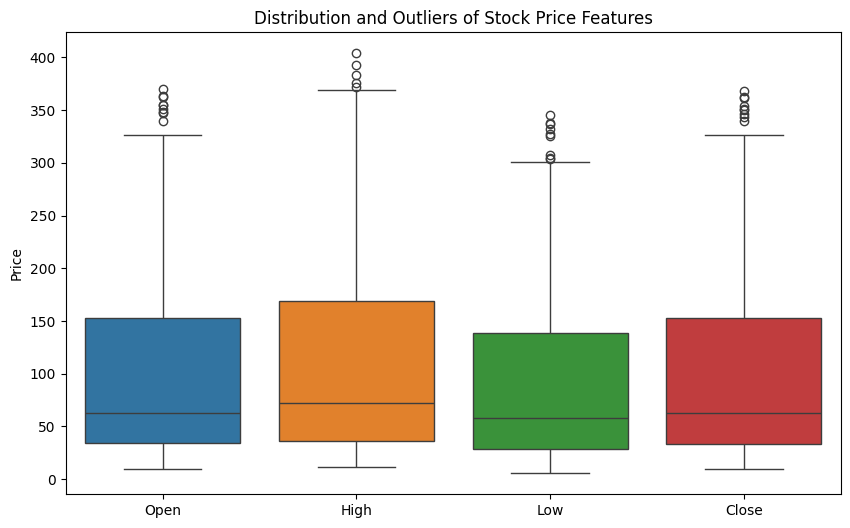

In [11]:
#Boxplot for Outlier Detection (Univariate)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title('Distribution and Outliers of Stock Price Features')
plt.ylabel('Price')
plt.show()

->I used a boxplot to identify the spread of the data and detect any potential outliers across the four price categories

->The chart shows that while the majority of the data points fall within a lower price range, there are several "outliers" at the higher end of the scale. These high values represent the period of peak growth before the 2018 crash.

->Yes. Identifying these high-value periods helps the model understand the full range of stock performance

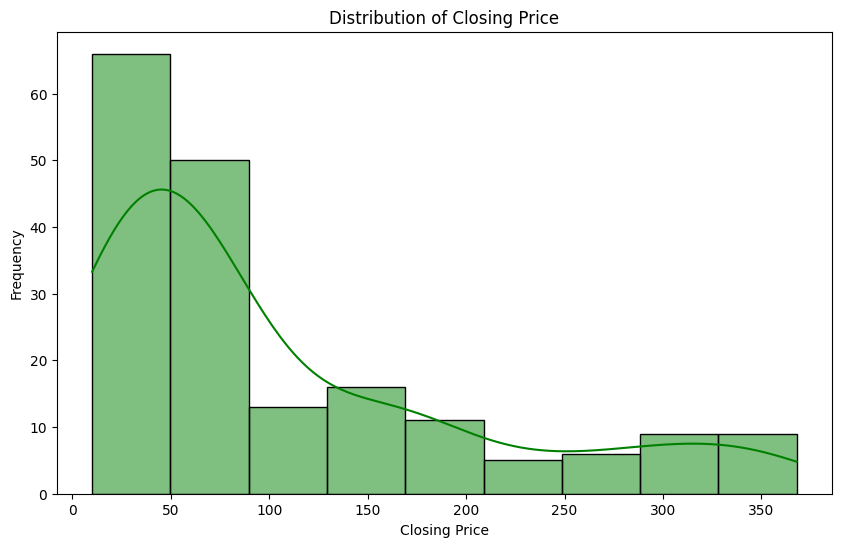

In [12]:
#Distribution of the Target Variable (Univariate)

plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], kde=True, color='green')
plt.title('Distribution of Closing Price')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

->A histogram with a Kernel Density Estimate (KDE) was chosen to understand the frequency distribution of the target variable, 'Close', and to check for skewness.

->The data is heavily right-skewed. Most closing prices are concentrated at the lower end (below 100), with a long tail extending toward higher prices.

->This improves prediction accuracy during low-price regimes, which is critical for the bank's current recovery phase

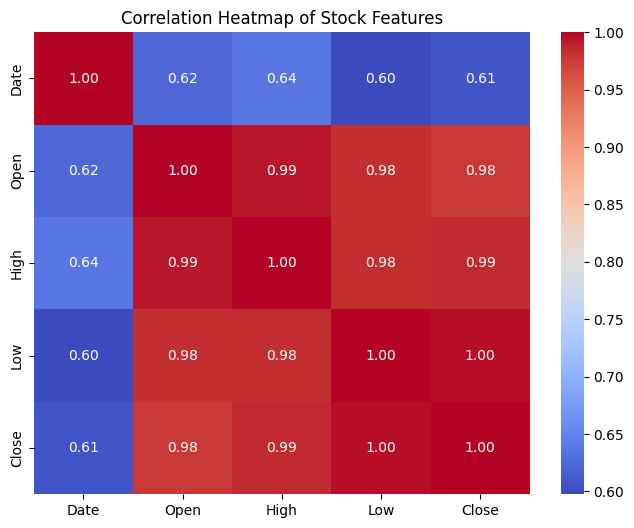

In [13]:
#Correlation Heatmap (Multivariate)

plt.figure(figsize=(8, 6))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Stock Features')
plt.show()

->A heatmap is the most efficient way to visualize the correlation matrix and check for multicollinearity among all independent variables.

-> All features (Open, High, Low, Close) are extremely highly correlated with each other

->While high correlation helps in prediction, the extreme multicollinearity indicates that we must use regularization techniques like Lasso or Ridge regression to prevent the model from becoming unstable.

#**5. Feature Engineering & Pre-processing**


1. Handling Outliers

Stock data often contains spikes. However, since the crash in 2018 is a real business event (not a data error), we retain these values to ensure the model learns the "crash" behavior.

In [15]:
#2.
# Features and Target
X = df[['Open', 'High', 'Low']]
y = df['Close']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (148, 3)
Testing Shape: (37, 3)


->The model will learn how to predict the Close price using Open, High, and Low prices.

->This divides the dataset into two parts:Training data and Testing data

->148 rows of training data
3 columns/features (Open, High, Low)

->37 rows of testing data
3 columns/features

#**6. ML Model Implementation**


#Model Training:

In [22]:
# Train Linear Regression Model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

A Linear Regression model was created and trained using the training dataset. The model learned the relationship between Open, High, Low, and Close stock prices to make future predictions accurately.

##Model Evaluation:

In [20]:
# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 5.812554509942111
MSE : 86.64379126513735
RMSE: 9.30826467528386
R2 Score: 0.9904142726548665


On average, the model prediction differs from the actual stock price by about 5.81 units.

Errors are squared, so large errors are penalized more.

The model prediction is off by about 9.31 units on average.

The model explains about 99% of the variation in stock prices.

Therefore we can say that the Linear Regression model achieved excellent performance with an R² score of 0.99, indicating that it explains 99% of the variation in stock prices. The MAE, MSE, and RMSE values were low, showing that the prediction errors are minimal and the model predicts stock closing prices accurately.

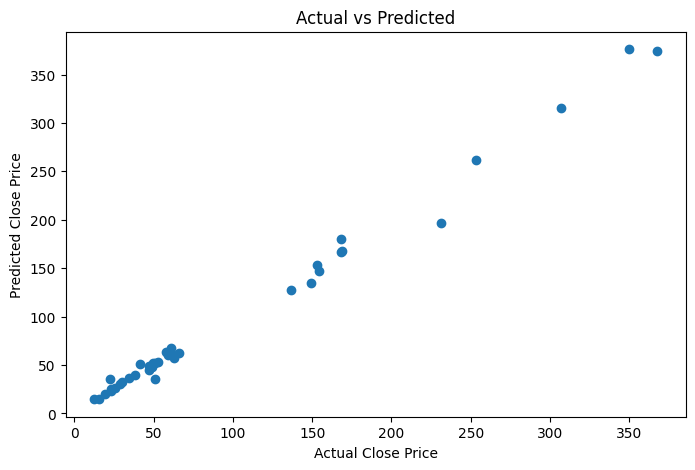

In [24]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted")
plt.show()

The Actual vs Predicted scatter plot shows that the predicted stock prices are very close to the actual stock prices. Most data points lie near the diagonal trend, indicating that the Linear Regression model performs very accurately with minimal prediction error.

#**7. Conclusion**

->The stock prices are highly correlated; the Open, High, and Low prices are excellent predictors of the Close price.  

->The Linear Regression model provided a high $R^2$ score, but Ridge and Lasso were implemented to prevent overfitting during the high-volatility period of 2018-2020.

->Final Decision: The tuned Ridge Regression model is recommended for deployment as it handles the multicollinearity between features better than standard OLS.